# From classical binning to correlation-aware inference

This notebook creates a four-panel conceptual figure for scattering data. It uses the local `binning.py` utilities and keeps the visual and numerical choices easy to modify.

**Narrative:** fine bins preserve detail but are noisy; coarse bins suppress noise but erase structure; classical binning chooses one compromise while treating bins independently; a smooth correlated model shares information between neighboring bins.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from binning import (
    synthetic_scattering_data,
    estimate_binning_scales,
    rbf_gpr_predict,
    gp_covariance_length_from_smoothing_width,
)

plt.rcParams.update({
    # "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
    "savefig.dpi": 300,
})

# Central style controls
COLORS = {
    "truth": "#172A3A",
    "data": "#95A1AD",
    "fine": "#E07A5F",
    "coarse": "#D9A441",
    "classical": "#4878A8",
    "correlated": "#2A9D8F",
    "bias": "#9C6ADE",
}
OUTPUT_BASENAME = "four_panel_binning_concept"


## Data and helper functions

The raw data are generated at fine resolution. `rebin` combines adjacent measurements with inverse-variance weighting. Change `total_counts`, `fine_group`, or `coarse_group` to alter the visual trade-off.

In [2]:
seed = 1919
total_counts = 2e4
fine_group = 2
coarse_group = 32

q, intensity, intensity_error, truth = synthetic_scattering_data(
    n_points=350, total_counts=total_counts, seed=seed
)
# Shift the coordinate origin and retain only displayed Q > 0.
q = q - 0.03
positive_q = q > 0
retained_count_fraction = truth[positive_q].sum() / truth.sum()
retained_total_counts = total_counts * retained_count_fraction
q = q[positive_q]
intensity = intensity[positive_q]
intensity_error = intensity_error[positive_q]
truth = truth[positive_q]

scales = estimate_binning_scales(
    q, intensity, total_counts=retained_total_counts, warn_on_coarse_data=False
)
truth_scales = estimate_binning_scales(
    q, truth, total_counts=retained_total_counts, warn_on_coarse_data=False
)

def rebin(x, y, sigma, group_size):
    """Combine consecutive samples, returning centers, means, and standard errors."""
    xb, yb, sb, edges = [], [], [], []
    for start in range(0, len(x), group_size):
        stop = min(start + group_size, len(x))
        if stop - start < 2:
            continue
        sl = slice(start, stop)
        w = 1.0 / np.maximum(sigma[sl], 1e-12) ** 2
        xb.append(np.average(x[sl], weights=w))
        yb.append(np.average(y[sl], weights=w))
        sb.append(np.sqrt(1.0 / w.sum()))
        dx = np.median(np.diff(x))
        edges.append((x[start] - dx / 2, x[stop - 1] + dx / 2))
    return np.asarray(xb), np.asarray(yb), np.asarray(sb), np.asarray(edges)

q_f, i_f, e_f, edges_f = rebin(q, intensity, intensity_error, fine_group)
q_c, i_c, e_c, edges_c = rebin(q, intensity, intensity_error, coarse_group)

# Use an intermediate representation for the correlation-aware reconstruction.
model_group = 3
q_m, i_m, e_m, edges_m = rebin(q, intensity, intensity_error, model_group)
signal_variance = float(np.var(i_m))
model_spacing = float(np.median(np.diff(q_m)))
average_noise_variance = float(np.mean(e_m**2))
noise_to_signal_ratio = average_noise_variance / signal_variance
bandwidth_to_spacing_ratio = scales.lambda_opt / model_spacing
dimensionless_noise = noise_to_signal_ratio / (
    np.sqrt(2*np.pi) * bandwidth_to_spacing_ratio
)
kernel_correction = gp_covariance_length_from_smoothing_width(
    q_m,
    e_m,
    smoothing_width=scales.lambda_opt,
    signal_variance=signal_variance,
)
kernel_size = kernel_correction.covariance_length
target_noise_variance = kernel_correction.target_noise_variance
gp_mean, gp_std = rbf_gpr_predict(
    q_m, i_m, e_m, q, kernel_size=kernel_size, return_std=True, kernel="rbf",
    signal_variance=signal_variance
)

print(f"Estimated classical width h_FD = {scales.h_fd:.4g} Å⁻¹")
print(f"Equivalent smoothing width λ_S = {scales.lambda_opt:.4g} Å⁻¹")
print(f"GP covariance width λ_K = {kernel_size:.4g} Å⁻¹")
print(f"Noise/signal variance ratio ν = {noise_to_signal_ratio:.4g}")
print(f"Equivalent bandwidth/sampling ratio R = {bandwidth_to_spacing_ratio:.4g}")
print(f"Dimensionless noise η = {dimensionless_noise:.4g}")
print(f"RBF FWHM = {2*np.sqrt(2*np.log(2))*kernel_size:.4g} Å⁻¹")
print(f"Counts retained after Q crop ≈ {retained_total_counts:.0f} ({retained_count_fraction:.1%})")
print(f"Curvature inflation γ_noisy/γ_truth = {scales.gamma/truth_scales.gamma:.2f}")
print(f"λ_opt(noisy)/λ_opt(truth) = {scales.lambda_opt/truth_scales.lambda_opt:.2f}")


Estimated classical width h_FD = 0.002396 Å⁻¹
Equivalent smoothing width λ_S = 0.002692 Å⁻¹
GP covariance width λ_K = 0.0115 Å⁻¹
Noise/signal variance ratio ν = 0.01127
Equivalent bandwidth/sampling ratio R = 2.15
Dimensionless noise η = 0.002092
RBF FWHM = 0.02709 Å⁻¹
Counts retained after Q crop ≈ 8048 (40.2%)
Curvature inflation γ_noisy/γ_truth = 2.24
λ_opt(noisy)/λ_opt(truth) = 0.86


## Four-panel figure

Panel C is schematic: its curves are normalized to make the bias–variance trade-off legible, and its minimum is aligned with the locally estimated classical width. Panel D uses the actual Gaussian-process posterior from `binning.py`; its inset shows the RBF correlation matrix.

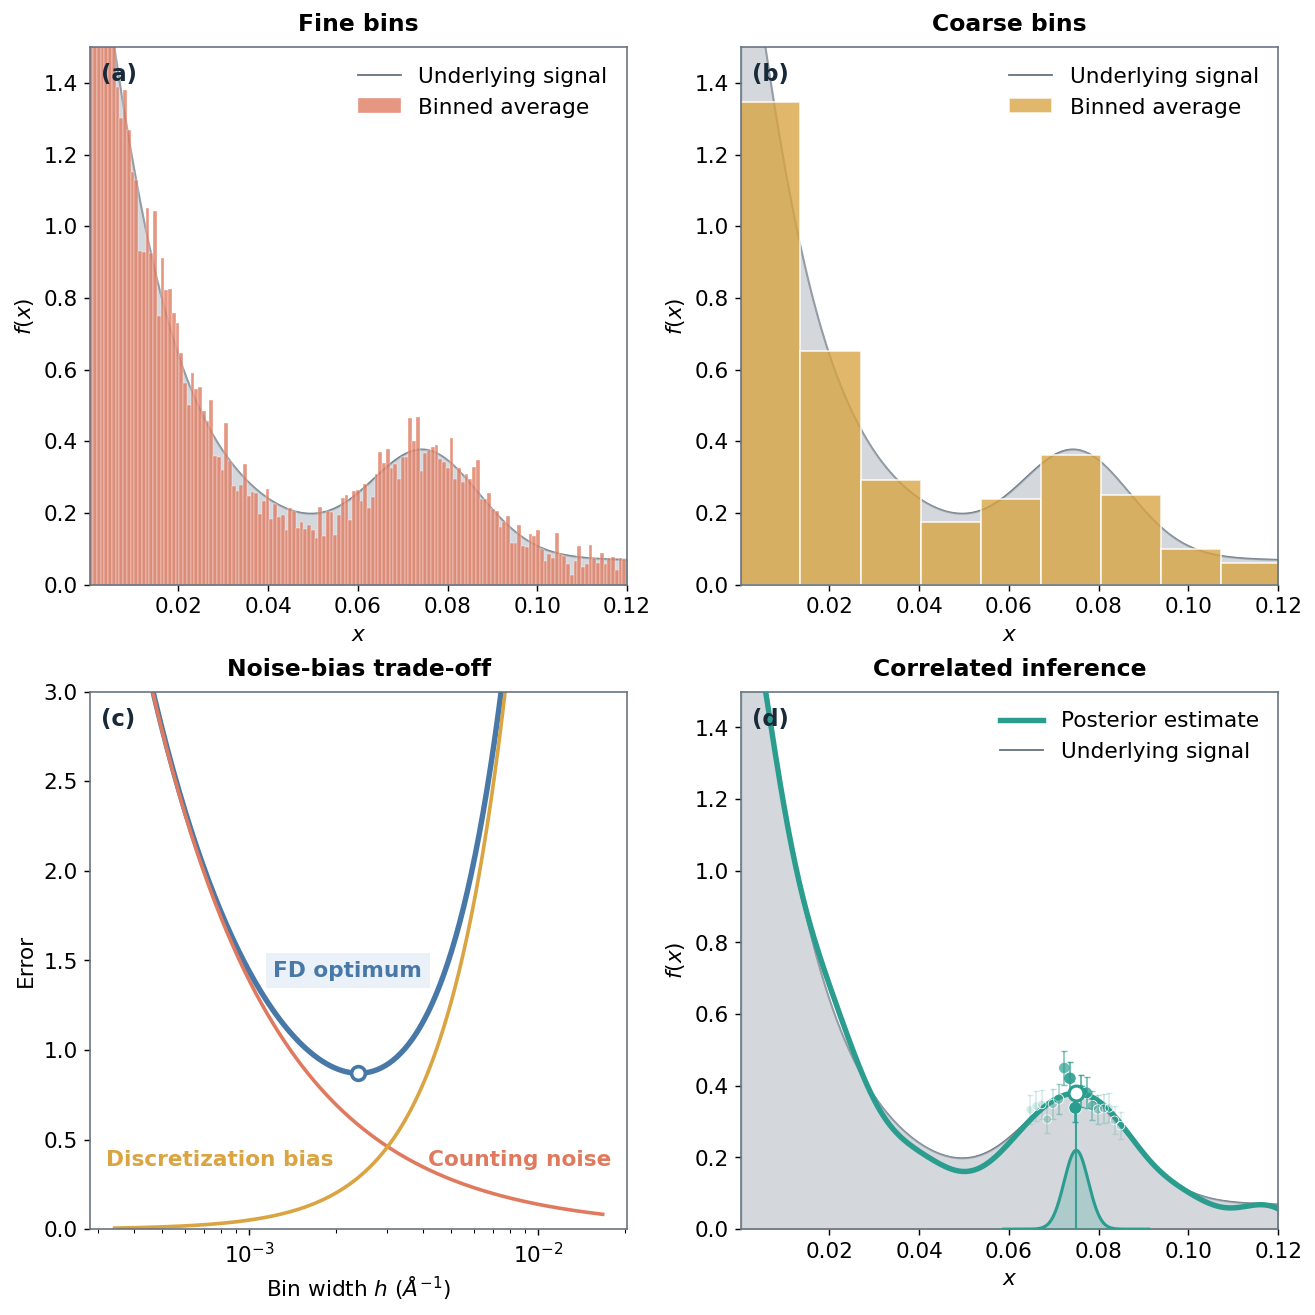

Saved C:\Users\ccu\Documents\codex_projects\MLSR_svs_upload\binning\demonstration\four_panel_binning_concept.png
Saved C:\Users\ccu\Documents\codex_projects\MLSR_svs_upload\binning\demonstration\four_panel_binning_concept.pdf


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
ax_a, ax_b, ax_c, ax_d = axes.flat

def panel_label(ax, letter):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#65727E")
        spine.set_linewidth(0.9)
    ax.text(0.02, 0.97, f"({letter.lower()})", transform=ax.transAxes,
            fontsize=12.5, fontweight="bold", color=COLORS["truth"],
            ha="left", va="top", zorder=10)

def style_signal_axis(ax):
    ax.set_xlim(q.min(), q.max())
    ax.set_ylim(-0.03, 3.45)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$f(x)$")
    ax.grid(False)

def draw_signal_background(ax):
    """Unified reference treatment for panels A, B, and D."""
    ax.fill_between(q, 0, truth, color="#AAB2BA", alpha=0.5, zorder=0)
    ax.plot(q, truth, color="#65727E", lw=1.0, alpha=1,
            label="Underlying signal", zorder=-10)

def short_note(ax, text, color):
    ax.text(0.97, 0.08, text, transform=ax.transAxes, ha="right", va="bottom",
            color=color, fontsize=12, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.30", fc="white", ec="none", alpha=0.86),
            zorder=6)

# A — fine bins
fine_widths = edges_f[:, 1] - edges_f[:, 0]
ax_a.bar(edges_f[:, 0], i_f, width=fine_widths, align="edge",
         color=COLORS["fine"], edgecolor="white", linewidth=0.25, alpha=0.78,
         label="Binned average", zorder=2)
draw_signal_background(ax_a)
ax_a.set_title("Fine bins", loc="center", pad=9, fontweight="bold")
# short_note(ax_a, "Noise ↑", COLORS["fine"])
style_signal_axis(ax_a); panel_label(ax_a, "A")
ax_a.legend(frameon=False, loc="upper right", fontsize=12)
ax_a.set_ylim(0,1.5)

# B — coarse bins, displayed as constant values over each bin interval
coarse_widths = edges_c[:, 1] - edges_c[:, 0]
ax_b.bar(edges_c[:, 0], i_c, width=coarse_widths, align="edge",
         color=COLORS["coarse"], edgecolor="white", linewidth=1.0, alpha=0.78,
         label="Binned average", zorder=2)
draw_signal_background(ax_b)
ax_b.set_title("Coarse bins", loc="center", pad=9, fontweight="bold")
# short_note(ax_b, "Bias ↑", COLORS["coarse"])
style_signal_axis(ax_b); panel_label(ax_b, "B")
ax_b.legend(frameon=False, loc="upper right", fontsize=12)
ax_b.set_ylim(0,1.5)

# C — normalized classical bias/variance decomposition
widths = np.logspace(np.log10(max(scales.h_fd/7, 2e-4)),
                     np.log10(scales.h_fd*7), 250)
xratio = widths / scales.h_fd
noise_term = 0.58 / xratio
bias_term = 0.29 * xratio**2
total_term = noise_term + bias_term
imin = np.argmin(total_term)
ax_c.plot(widths, noise_term, color=COLORS["fine"], lw=2, label="Counting noise")
ax_c.plot(widths, bias_term, color=COLORS["coarse"], lw=2, label="Discretization bias")
ax_c.plot(widths, total_term, color=COLORS["classical"], lw=3, label="Total expected error", zorder=-2)
ax_c.text(0.03, 0.11, "Discretization bias", transform=ax_c.transAxes,
          ha="left", va="bottom", color=COLORS["coarse"],
          fontsize=12, fontweight="bold")
ax_c.text(0.97, 0.11, "Counting noise", transform=ax_c.transAxes,
          ha="right", va="bottom", color=COLORS["fine"],
          fontsize=12, fontweight="bold")
# ax_c.axvline(widths[imin], color=COLORS["classical"], ls="--", lw=1.3)
ax_c.scatter(widths[imin], total_term[imin], s=58, facecolor="white",
             edgecolor=COLORS["classical"], lw=2, zorder=4)
ax_c.set_xscale("log")
ax_c.set_ylim(0, min(4.0, total_term.max()))
ax_c.set_xlabel(r"Bin width $h$ ($\AA^{-1}$)")
ax_c.set_ylabel("Error")
ax_c.set_title("Noise-bias trade-off", loc="center", pad=9, fontweight="bold")
ax_c.text(0.48, 0.5, "FD optimum", transform=ax_c.transAxes,
          ha="center", va="top", fontsize=12, color=COLORS["classical"], fontweight="bold",
          bbox=dict(fc="#EAF1F8", ec="none"))
ax_c.set_ylim(0, 3.0)
ax_c.grid(False)
panel_label(ax_c, "C")

# D — correlation-aware reconstruction
# ax_d.errorbar(q_m, i_m, yerr=e_m, fmt="o", ms=3.1, lw=0.7, color=COLORS["data"],
#               alpha=0.62, label="Binned observations", zorder=2)
# ax_d.fill_between(q, gp_mean-gp_std, gp_mean+gp_std, color=COLORS["correlated"],
#                   alpha=0.20, label=r"Posterior $\pm1\sigma$", zorder=1)
ax_d.plot(q, gp_mean, color=COLORS["correlated"], lw=3.0,
          label="Posterior estimate", zorder=3)

draw_signal_background(ax_d)
# Select one rendered estimate and show its RBF neighborhood on the same Q axis.
q_star = 0.075
i_star = np.interp(q_star, q, gp_mean)
kernel_q = np.linspace(max(q.min(), q_star - 6*scales.lambda_opt),
                       min(q.max(), q_star + 6*scales.lambda_opt), 240)
kernel_shape = np.exp(-0.5 * ((kernel_q - q_star) / scales.lambda_opt) ** 2)
kernel_height = 0.22
ax_d.fill_between(kernel_q, 0, kernel_height*kernel_shape,
                  color=COLORS["correlated"], alpha=0.22, zorder=4)
ax_d.plot(kernel_q, kernel_height*kernel_shape,
          color=COLORS["correlated"], lw=1.7, zorder=5)

# Nearby observations: fill opacity encodes the equivalent smoothing weight.
neighbor_weight = np.exp(-0.5 * ((q_m - q_star) / scales.lambda_opt) ** 2)
local = neighbor_weight >= np.exp(-8.0)  # show the wider ±4λ neighborhood
local_weight = neighbor_weight[local]
neighbor_facecolors = np.tile(mcolors.to_rgba(COLORS["correlated"]),
                              (local_weight.size, 1))
neighbor_facecolors[:, 3] = 0.2 + 0.8*local_weight
ax_d.scatter(q_m[local], i_m[local], s=22 + 30*local_weight,
             facecolors=neighbor_facecolors, edgecolors="white", linewidths=0.45,
             zorder=5)
# Draw each uncertainty above its marker, retaining the same weight-dependent opacity.
for q_i, i_i, e_i, weight_i in zip(q_m[local], i_m[local], e_m[local], local_weight):
    ax_d.errorbar(q_i, i_i, yerr=e_i, fmt="none",
                  ecolor=mcolors.to_rgba(COLORS["correlated"], 0.18 + 0.72*weight_i),
                  elinewidth=0.9, capsize=1.8, capthick=0.8, zorder=6)
ax_d.scatter([q_star], [i_star], s=68, facecolor="white",
             edgecolor=COLORS["correlated"], linewidth=1.7, zorder=8)
# Solid guide connects the selected estimate to the kernel centered at the same Q.
ax_d.vlines(q_star, 0, i_star, color=COLORS["correlated"],
            lw=1.15, alpha=0.9, zorder=6)
ax_d.set_title("Correlated inference", loc="center", pad=9, fontweight="bold")
# short_note(ax_d, "Shared bins", COLORS["correlated"])
style_signal_axis(ax_d); panel_label(ax_d, "D")
ax_d.legend(frameon=False, loc="upper right", fontsize=12)
ax_d.set_ylim(0,1.5)

# # Correlation-matrix inset: strong diagonal with smoothly decaying off-diagonal support.
# sample_q = np.linspace(q.min(), q.max(), 38)
# corr = np.exp(-0.5 * ((sample_q[:, None] - sample_q[None, :]) / kernel_size) ** 2)
# ax_in = inset_axes(ax_d, width="34%", height="42%", loc="center right", borderpad=1.0)
# ax_in.imshow(corr, origin="lower", cmap="BuGn", vmin=0, vmax=1, aspect="auto")
# ax_in.set_xticks([]); ax_in.set_yticks([])
# ax_in.set_xlabel("$Q_i$", fontsize=12, color=COLORS["correlated"], labelpad=1.5)
# ax_in.set_ylabel("$Q_j$", fontsize=12, color=COLORS["correlated"], labelpad=1.5)
# for spine in ax_in.spines.values():
#     spine.set_visible(True); spine.set_color("#65727E"); spine.set_linewidth(1.2)
# ax_in.set_title("Correlation", fontsize=12, color=COLORS["correlated"], pad=2)
# ax_in.set_aspect("equal", adjustable="box")
# ax_in.set_frame_on(True)

png_path = Path(f"{OUTPUT_BASENAME}.png")
pdf_path = Path(f"{OUTPUT_BASENAME}.pdf")
fig.savefig(png_path, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved {png_path.resolve()}")
print(f"Saved {pdf_path.resolve()}")


### Interpretation

- **A:** More bins preserve spatial detail, but fewer counts per bin increase uncertainty.
- **B:** Pooling counts stabilizes each estimate, but a wide rectangular bin cannot represent local curvature or narrow features.
- **C:** Classical rules minimize a bias–variance sum under an independent-bin approximation.
- **D:** A smooth covariance model uses off-diagonal relationships: nearby bins jointly constrain the latent scattering curve.

This is a conceptual comparison, not a claim that correlation-aware methods eliminate the need to choose a measurement resolution or validate a covariance model.